In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('repo/PatHoST')

# Library

In [3]:
import src.predict as predict
import src.metrics as metrics
import src.utils as utils

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
import anndata as ad
from pathlib import Path
from joblib import dump, load
import gc
import warnings
warnings.filterwarnings("ignore")

In [4]:
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Define Palette

In [54]:
pred_cmap = LinearSegmentedColormap.from_list("pred_cmap",[(0,"lightgray"),(0.4,'lightgrey'), (1,"#C03830")])
pred_palette = {0: "lightgray",1:"#c09530"  , 2: "#C03830",}

# Load Dataset

In [11]:
spdata=load('../../GROUND_TRUTH/DATA/SPDATA.h5ad')
#spdata=load('data/SPDATA.h5ad')

# Load Models

In [6]:
models=load('models/CLASS_LOGmRFmXGBd0.0_TRAIN123456.h5ad')

In [10]:
model=models['GT2_0.0']['norm']['Y_GT2_x1_z0.5_GlobalXnorm'][0.7]['RandomForest']['model']
subkey='Y_GT2_x1_z0.5_GlobalXnorm'

# Predict - scores

In [16]:
pred=predict.BacterialClassifierPrediction(spdata,'Ext_3',x='dataXNorm',model=model,type='RandomForest')

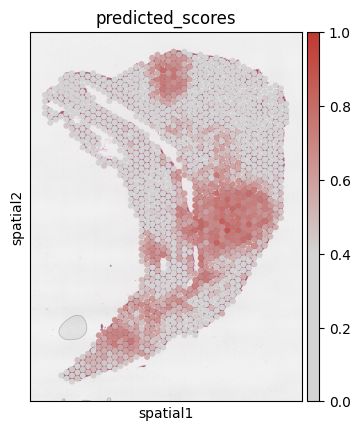

In [27]:
dummy=spdata['Ext_3']['dataXNorm'].copy()

dummy.obs['predicted_scores']=pred

sc.pl.spatial(dummy,color='predicted_scores',size=1.5,cmap=pred_cmap,vmin=0,vmax=1)

# Clustering - Metrics

## Extract True Labels

In [57]:
dummy=spdata['Ext_3']['Y__x1_GlobalXnorm'].copy()

dummy.obs['predicted_scores']=pred

l=np.sum(dummy[:,['rpoB','MAB_0545']].X.toarray(),axis=1)

lq=l>np.quantile(l,0.7)

dummy.obs['true_labels']=lq.astype(int)

true_labels=dummy.obs['true_labels'].values

## Compute clustering and metrics of clustering

In [58]:
results_df, labels_df = metrics.evaluate_all_methods(
    pred_scores=pred, 
    true_labels=true_labels, 
    fcmin=0.3, 
    fcmax=0.7
)

In [59]:
print("Metrics resume:")
print(results_df)

Metrics resume:
                Silhouette  Calinski_Harabasz  F1_Score  ARI_Mean   ARI_Std
Method                                                                     
Median Cutoff     0.573540        2949.907207  0.154667  0.942706  0.056723
KMeans 3          0.564007        4369.279391  0.236776  0.863576  0.077025
KMeans 2          0.619868        3567.980978  0.187291  0.939772  0.048673
Hierarchical 3    0.540440        3778.956842  0.196078  0.499308  0.175289
Hierarchical 2    0.620907        3408.668355  0.196078  0.664138  0.239472
FCM 3             0.389448        2757.486412  0.196078  0.964112  0.022893


## Viz

In [60]:
for col in labels_df.columns:
    col_name = col.lower().replace(" ", "_") + "_label" # es. 'KMeans 3' -> 'kmeans_3_label'
    dummy.obs[col_name] = labels_df[col].values.astype(str)

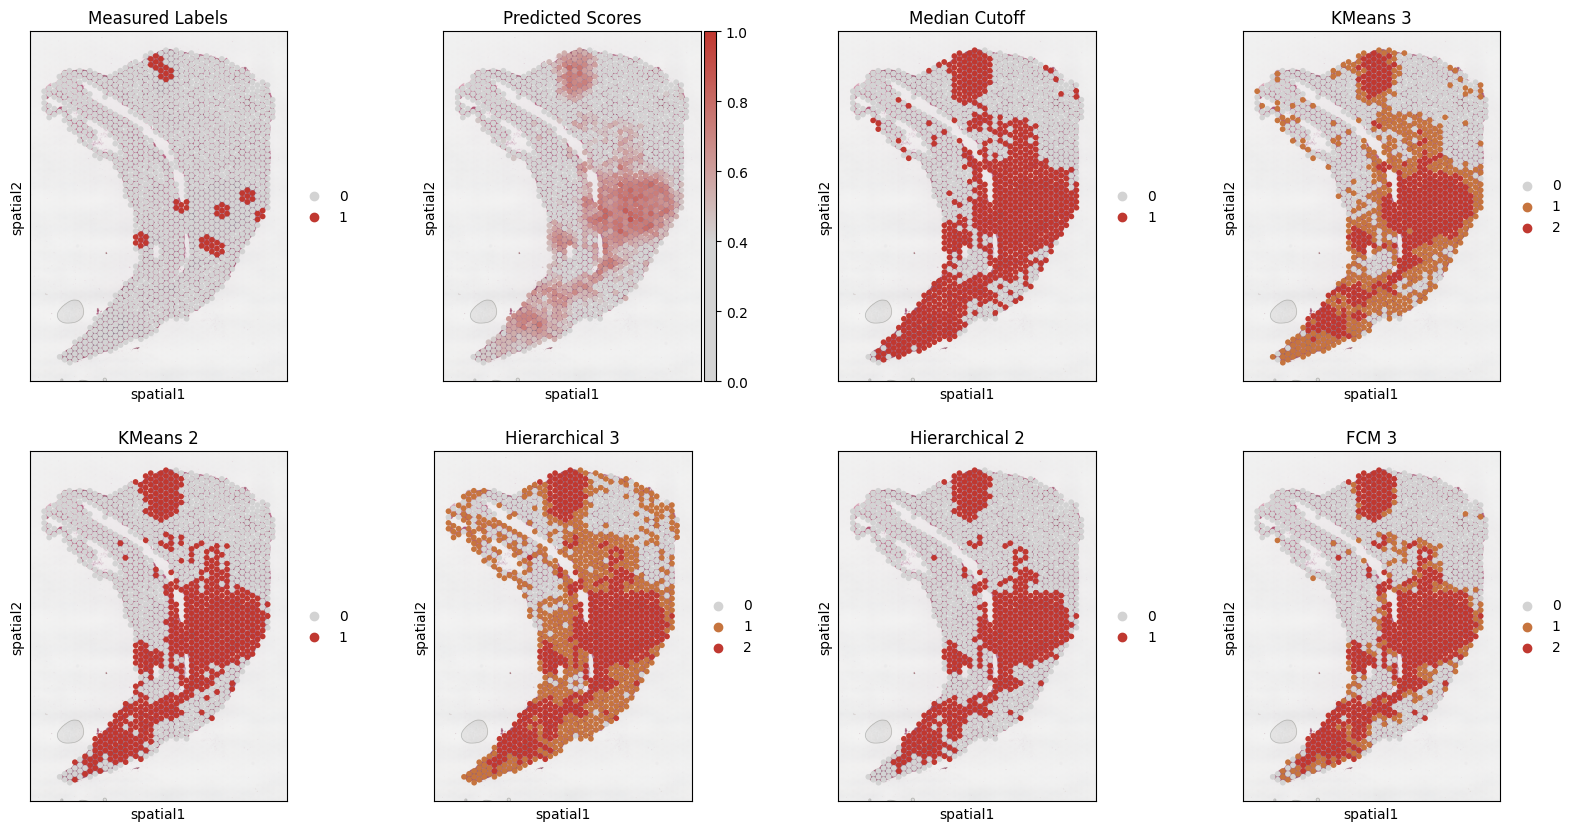

In [66]:
Clustering_type=len(labels_df.columns)

fig, ax = plt.subplots(2, 4, figsize=(20,10))

ax=ax.flatten()

dummy.obs['true_labels']=true_labels.astype(str)

sc.pl.spatial(dummy, color='true_labels', size=1.5, palette={'0': "lightgray", '1': "#C03830"}, title='Measured Labels', ax=ax[0], show=False)

sc.pl.spatial(dummy, color='predicted_scores', size=1.5, cmap=pred_cmap, vmin=0, vmax=1, title='Predicted Scores', ax=ax[1], show=False)

for i in range(Clustering_type):
	col_name = labels_df.columns[i].lower().replace(" ", "_") + "_label"
	cluster_levels=labels_df[labels_df.columns[i]].nunique()
	palette = {'0': "lightgray", '1': "#c6743e", '2': "#C03830"} if cluster_levels==3 else {'0': "lightgray", '1': "#C03830"}
	sc.pl.spatial(dummy, color=col_name, size=1.5, palette=palette, title=labels_df.columns[i], ax=ax[i+2], show=False)